In [6]:
import sys; sys.path += ['./../']
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from umap import UMAP
import scipy
import matplotlib.patches as mpatches
import scipy
import os

# ✅ Option : calculer UMAP uniquement sur adata_full

def plot_results_rna_clean(project_on_full, p, combo, stim, prior, normlog=True):
    
    # ---------- Chargement ----------
    adata_full = ad.read_h5ad(p + 'cardamomOT/adata_beta.h5ad')
    adata_sim = ad.read_h5ad(p + 'cardamomOT/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_perturb_path = os.path.join(
        p, f'cardamomOT/adata_sim_{combo}_stim{stim}_prior{prior}.h5ad'
    )
    adata_KOV = ad.read_h5ad(adata_perturb_path)

    def enforce_cell_type_order(adata, class_order, label_key='cell_type'):
        if label_key in adata.obs:
            adata.obs[label_key] = pd.Categorical(adata.obs[label_key],
                                                  categories=class_order, ordered=True)

    adatas = [adata_full, adata_sim, adata_KOV]
    names = ["Train", "Sim", "{}".format(combo)]

    # Harmoniser l'ordre des cell types si présent
    class_order = None
    if "cell_type" in adata_full.obs:
        class_order = adata_full.obs['cell_type'].astype(str).unique().tolist()
        for A in adatas:
            enforce_cell_type_order(A, class_order)

    # donner des obs_names uniques + source
    for name, A in zip(names, adatas):
        A.obs_names = [f"{name}_{i}" for i in range(A.n_obs)]
        A.obs["source"] = name

    # ---------- UMAP / projection ----------
    reducer = UMAP(random_state=42, min_dist=.7)

    if project_on_full:
        if normlog:
            sc.pp.normalize_total(adata_full, target_sum=1e4)
            sc.pp.log1p(adata_full)
        
        X_input = adata_full.X.toarray() if scipy.sparse.issparse(adata_full.X) else adata_full.X
        adata_full.obsm["X_umap"] = reducer.fit_transform(X_input)

        proj = reducer.fit(X_input)
        adata_full.obsm["X_umap"] = proj.embedding_  # plus fidèle à fit()
        for A in [adata_sim, adata_KOV]:
            if normlog:
                sc.pp.normalize_total(A, target_sum=1e4)
                sc.pp.log1p(A)
            X_input = A.X.toarray() if scipy.sparse.issparse(A.X) else A.X
            A.obsm["X_umap"] = proj.transform(X_input)

    else:
        adata_all = ad.concat(adatas, join='inner', label='source', keys=names)
        if normlog:
            sc.pp.normalize_total(adata_all, target_sum=1e4)
            sc.pp.log1p(adata_all)
        X_input = adata_all.X.toarray() if scipy.sparse.issparse(adata_all.X) else adata_all.X
        proj = reducer.fit(X_input)
        adata_all.obsm["X_umap"] = proj.transform(X_input)
        for name, A in zip(names, adatas):
            A.obsm["X_umap"] = adata_all[adata_all.obs['source'] == name].obsm["X_umap"]
            # note : on suppose que l'ordre/indices correspondent ; si pas fiable, on peut indexer via .obs_names

    # ---------- FIGURE 1 : time (colorbar unique en bas) ----------
    # rassembler plage globale de time (si présent)
    time_values_all = []
    for A in adatas:
        if "time" in A.obs:
            tv = pd.to_numeric(A.obs["time"], errors='coerce').dropna()
            if tv.size > 0:
                time_values_all.append(tv.values)
    time_values_all = np.concatenate(time_values_all) if len(time_values_all) > 0 else np.array([])

    if time_values_all.size > 0:
        vmin, vmax = float(np.min(time_values_all)), float(np.max(time_values_all))
        fig1, axes1 = plt.subplots(1, len(adatas), figsize=(4 * len(adatas), 4), squeeze=False)
        scatter_ref = None
        for i, (A, name) in enumerate(zip(adatas, names)):

            ax = axes1[0, i]
            ax.set_title(name, fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])

            if "time" in A.obs:
                coords = A.obsm["X_umap"]
                tv = pd.to_numeric(A.obs["time"], errors='coerce').values
                # scatter with shared vmin/vmax
                scatter = ax.scatter(coords[:, 0], coords[:, 1], c=tv, cmap='viridis',
                                     vmin=vmin, vmax=vmax, s=6, linewidths=0, rasterized=True)
                scatter_ref = scatter  # keep last non-none for colorbar
            else:
                ax.axis('off')

        # colorbar horizontale en bas
        if scatter_ref is not None:
            cbar_ax = fig1.add_axes([0.12, 0.06, 0.76, 0.03])  # ajuster si besoin
            cb = fig1.colorbar(scatter_ref, cax=cbar_ax, orientation='horizontal')
            cb.set_label('time')
        fig1.tight_layout(rect=[0, 0.14, 1, 1])
        plt.show()
    else:
        print("No 'time' field found in any dataset — skipping time figure.")

    # ---------- FIGURE 2 : cell_type (légende horizontale unique en bas) ----------
    # définir catégories et palette
    if any("cell_type" in A.obs for A in adatas):
        if class_order is not None:
            categories = list(class_order)
        else:
            # agréger catégories présentes
            cats = []
            for A in adatas:
                if "cell_type" in A.obs:
                    cats.extend(A.obs["cell_type"].astype(str).unique().tolist())
            # conserver ordre unique
            categories = list(dict.fromkeys(cats))

        # palette (tab20 par défaut, recyclable si >20)
        cmap_cat = plt.get_cmap('Dark2')
        colors = [cmap_cat(i % 20) for i in range(len(categories))]
        color_map = {cat: colors[i] for i, cat in enumerate(categories)}

        fig2, axes2 = plt.subplots(1, len(adatas), figsize=(4 * len(adatas), 4), squeeze=False)
        for i, (A, name) in enumerate(zip(adatas, names)):
            ax = axes2[0, i]
            ax.set_title(name, fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])

            if "cell_type" in A.obs:
                coords = A.obsm["X_umap"]
                # pour garantir cohérence, on trace par catégorie
                for cat in categories:
                    mask = (A.obs["cell_type"].astype(str) == cat).values
                    if np.any(mask):
                        ax.scatter(coords[mask, 0], coords[mask, 1],
                                   color=color_map[cat], s=6, linewidths=0, rasterized=True)
            else:
                ax.axis('off')

        # légende commune : ne garder que les catégories présentes dans au moins un dataset
        present = [cat for cat in categories if any(
            ("cell_type" in A.obs) and (A.obs["cell_type"].astype(str) == cat).any() for A in adatas)]
        handles = [mpatches.Patch(color=color_map[cat], label=cat) for cat in present]
        if len(handles) > 0:
            # placer la légende horizontale en bas, dispatchée
            fig2.legend(handles, [h.get_label() for h in handles],
                        loc='lower center', ncol=len(handles),
                        frameon=False, bbox_to_anchor=(0.5, -0.12))
        fig2.tight_layout(rect=[0, 0.18, 1, 1])
        plt.show()
    else:
        print("No 'cell_type' field found in any dataset — skipping cell_type figure.")



def plot_results_prot(project_on_full, p, combo):

    # 📁 Chemin vers les fichiers
    adata_traj = ad.read_h5ad(p + 'cardamomOT/adata_prot_traj_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_simul = ad.read_h5ad(p + 'cardamomOT/adata_prot_simul_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_KOV = ad.read_h5ad(p + 'cardamomOT/adata_prot_simul{}_stim{}_prior{}.h5ad'.format(combo, stim, prior))

    # ⚙️ Lister les jeux de données avec leur nom
    adatas = [adata_traj, adata_simul, adata_KOV]
    names = ["Traj", "Sim", "{}".format(combo)]

    # 🔧 Source + noms uniques
    for name, adata in zip(names, adatas):
        adata.obs_names = [f"{name}_{i}" for i in range(adata.n_obs)]
        adata.obs["source"] = name

    reducer = UMAP(random_state=42, min_dist=.7)

    if project_on_full:
        # 🔬 Preprocessing sur adata_full

        X_input = adata_traj.X.toarray() if scipy.sparse.issparse(adata_traj.X) else adata_traj.X
        proj = reducer.fit(X_input)
        adata_traj.obsm["X_umap"] = proj.transform(X_input)

        # 🔁 Transformer les autres datasets avec le modèle entraîné
        # Preprocessing identique
        for adata in [adata_simul, adata_KOV]:
            
            # Projection UMAP
            X_input = adata.X.toarray() if scipy.sparse.issparse(adata.X) else adata.X
            adata.obsm["X_umap"] = proj.transform(X_input)


    else:

        # 🔗 Concaténation globale pour UMAP commune
        adata_all = ad.concat(adatas, join='inner', label='source', keys=names)

        X_input = adata_all.X.toarray() if scipy.sparse.issparse(adata_all.X) else adata_all.X
        proj = reducer.fit(X_input)
        adata_all.obsm["X_umap"] = proj.transform(X_input)

        for name, adata in zip(names, adatas):
            adata.obsm["X_umap"] = adata_all[adata.obs_names].obsm["X_umap"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for i, (adata, name) in enumerate(zip(adatas, names)):
        if "time" in adata.obs:
            sc.pl.umap(adata, color="time", ax=axes[i], show=False, title=f"{name} - time")
        else:
            sc.pl.umap(adata, ax=axes[i], show=False, title=f"{name} - time")

    plt.tight_layout()
    plt.show()




/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_25820/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


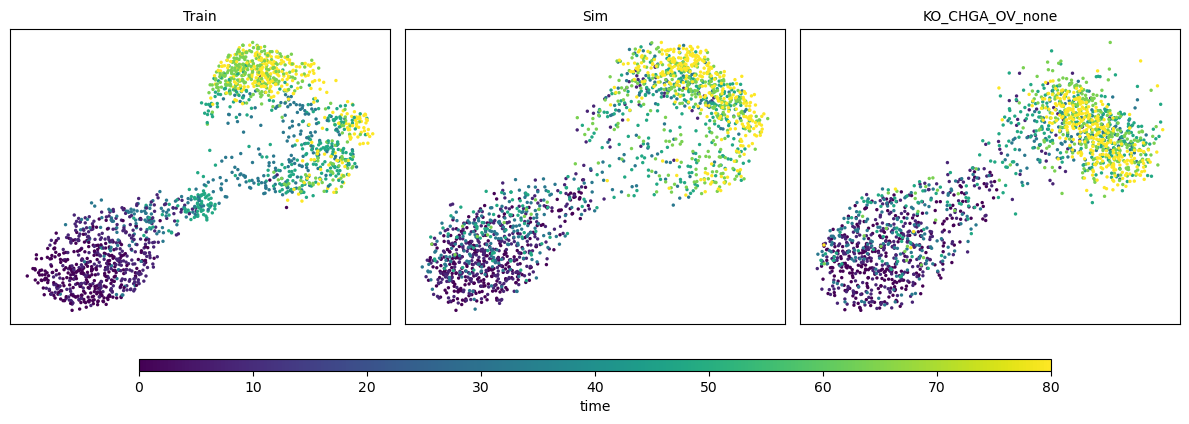

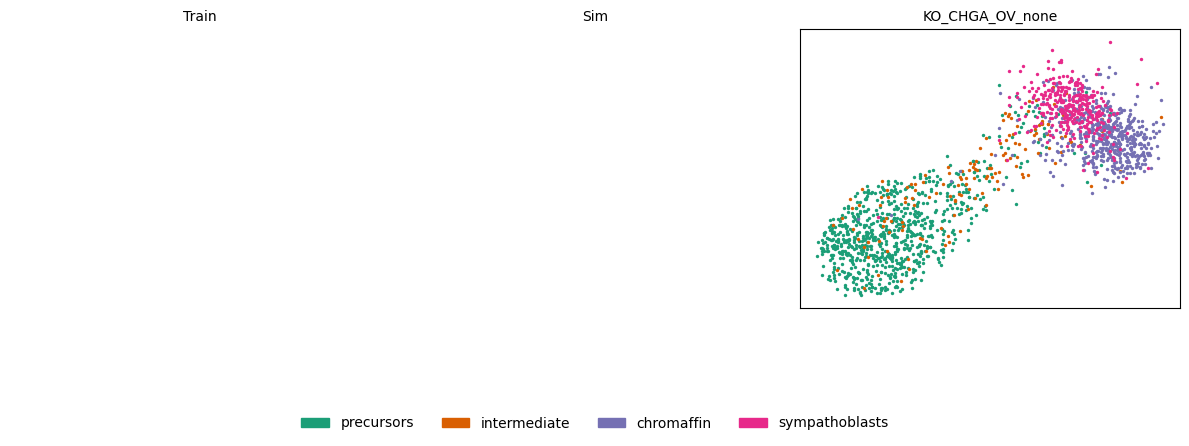

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_25820/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


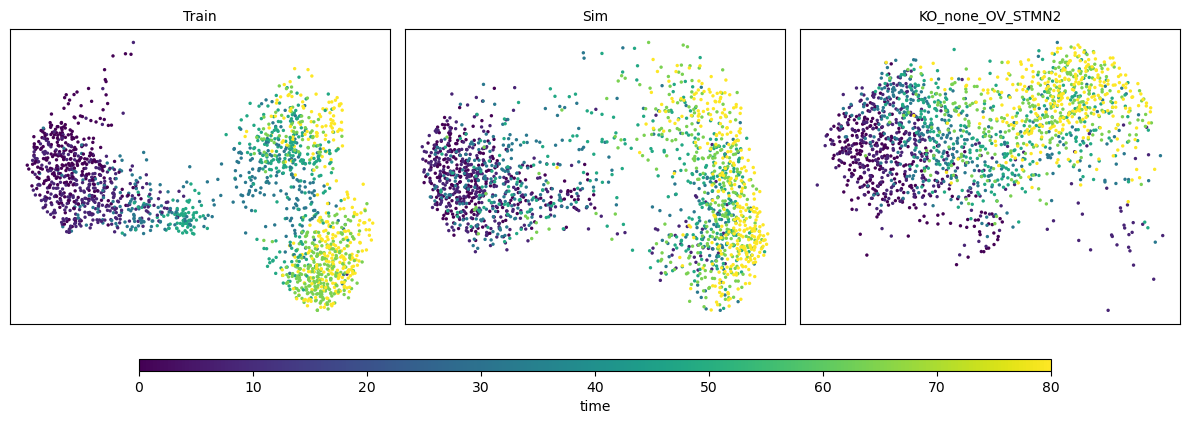

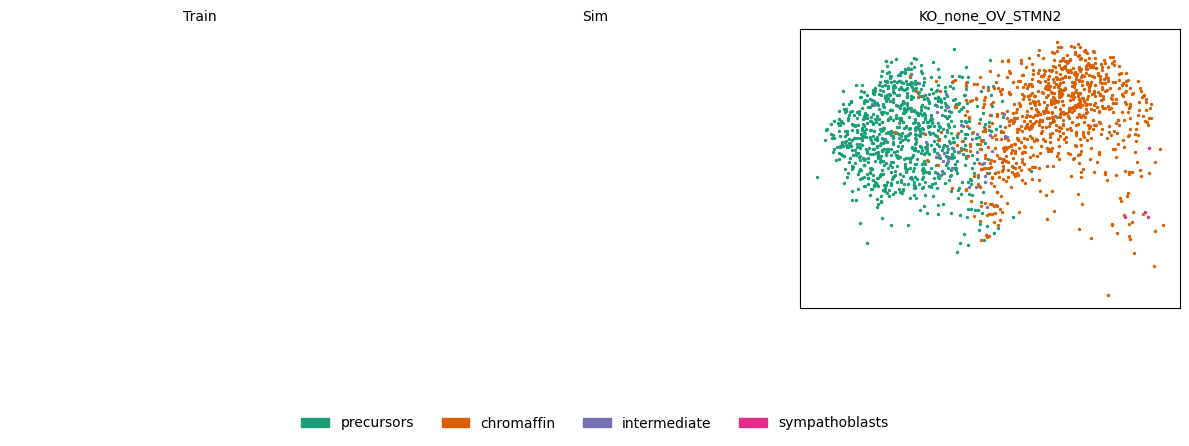

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_25820/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


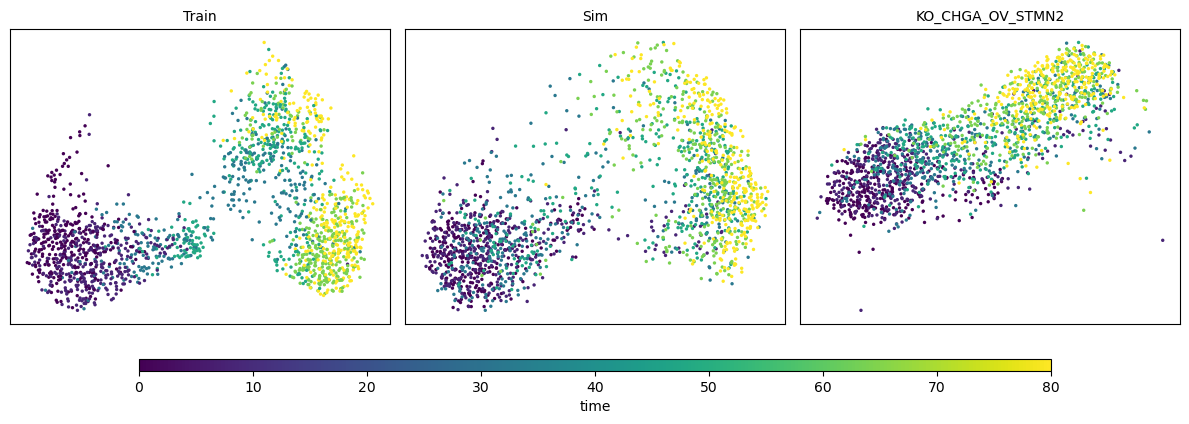

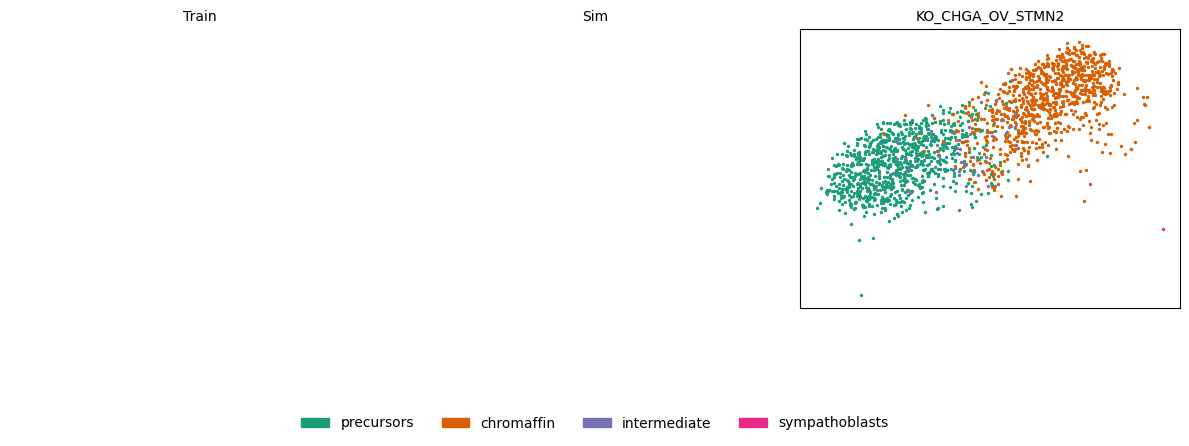

In [ ]:
p_all = './../experimental_datasets/Kameneva/'

plot_results_rna_clean(0, p_all,"KO_CHGA_OV_none", stim=1.0, prior=1.0)
plot_results_rna_clean(0, p_all,"KO_none_OV_STMN2", stim=1.0, prior=1.0)
plot_results_rna_clean(0, p_all,"KO_CHGA_OV_STMN2", stim=1.0, prior=1.0)

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_75543/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


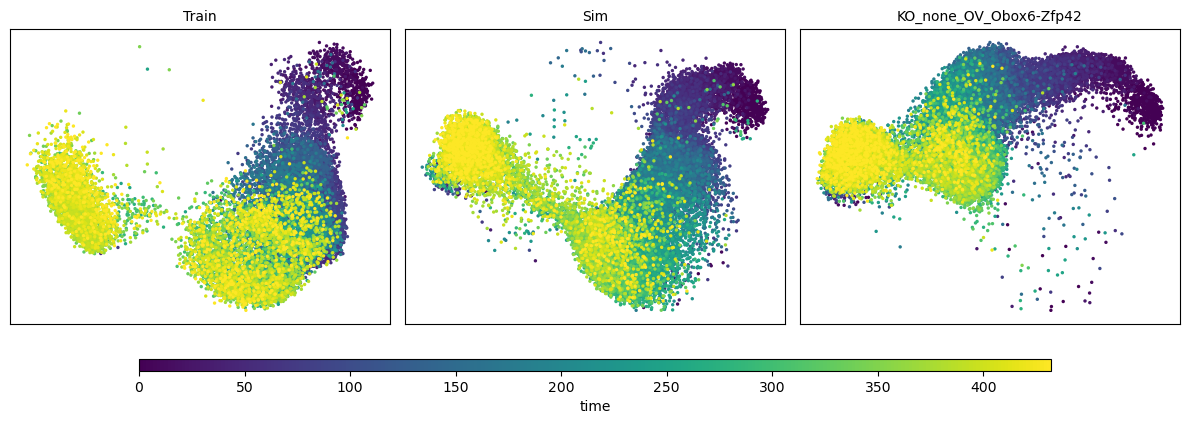

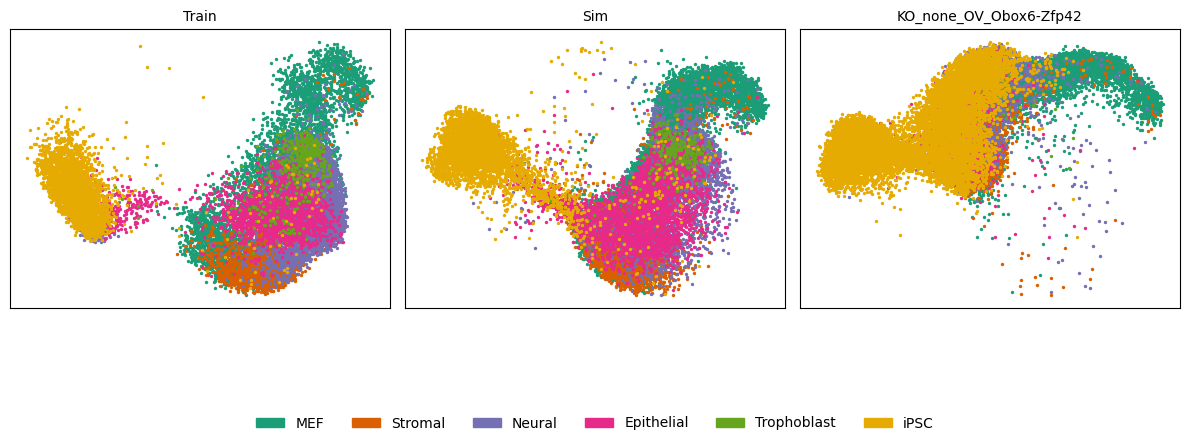

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_75543/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


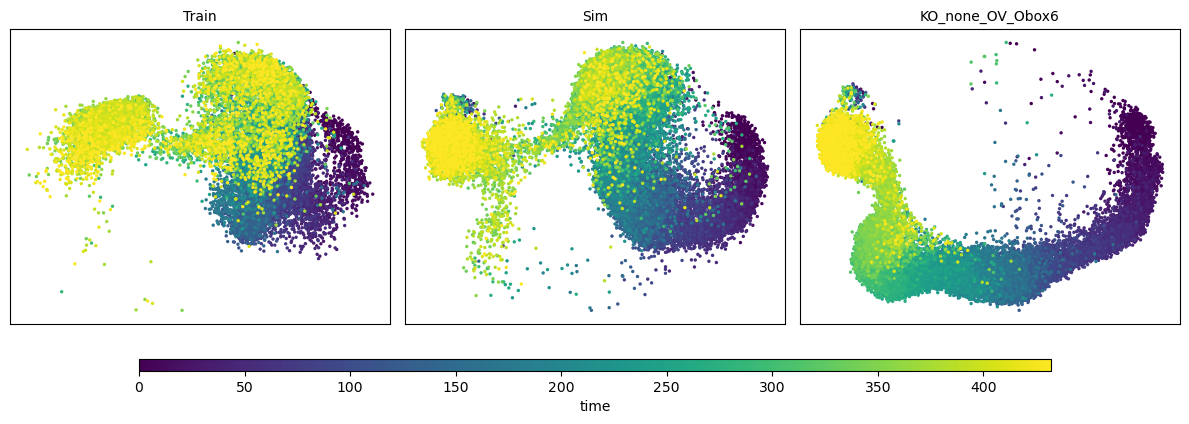

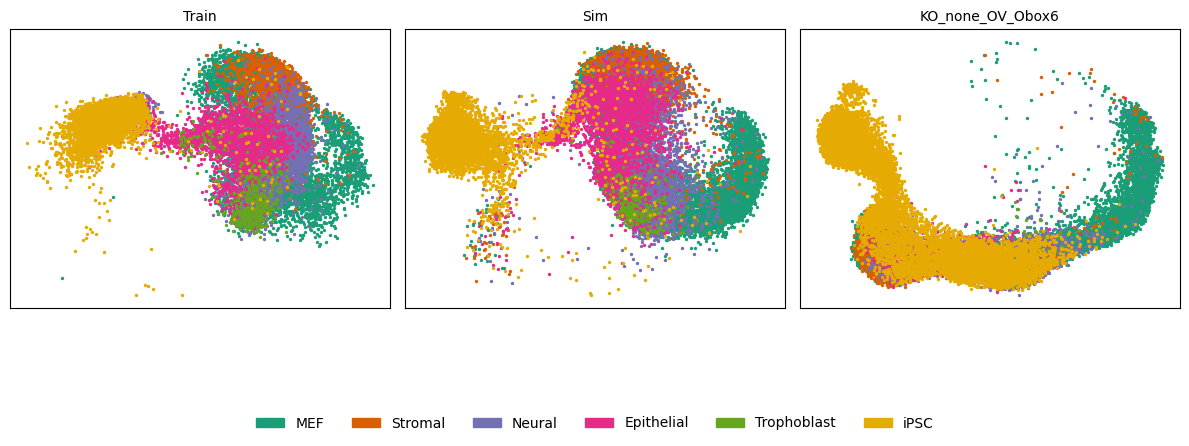

/opt/homebrew/Caskroom/miniconda/base/envs/cardamom_light/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/lj/409601z9289fp_pv32k6f3frf4h14r/T/ipykernel_75543/3768666520.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout(rect=[0, 0.14, 1, 1])


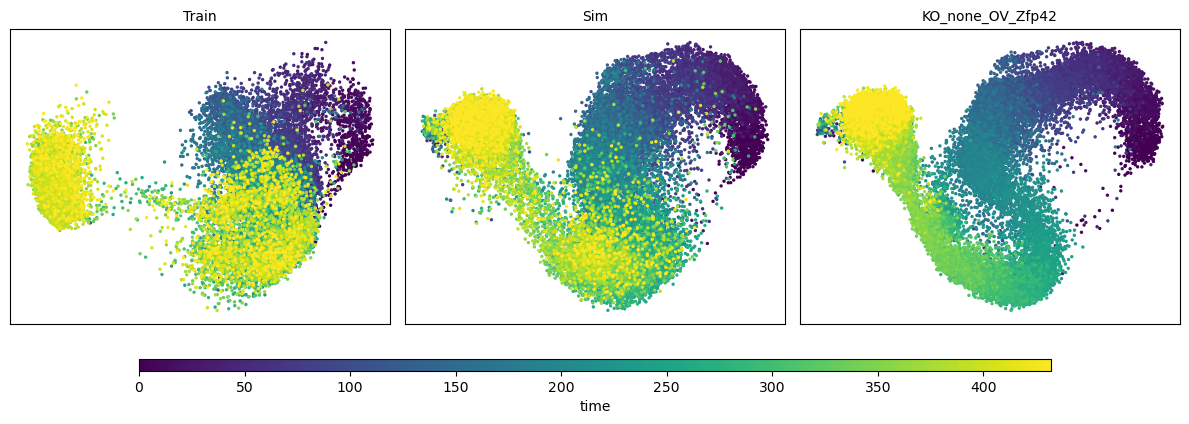

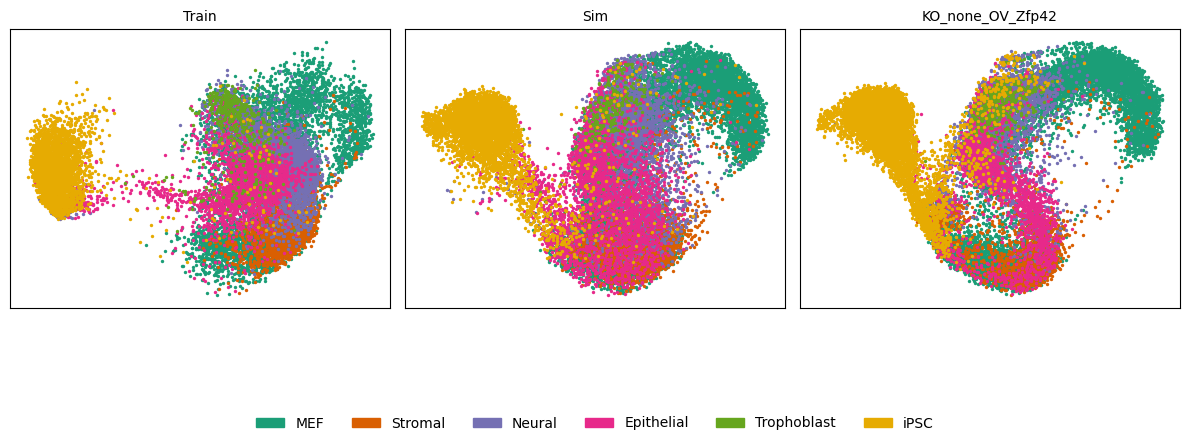

In [ ]:
p_S = './../experimental_datasets/Schiebinger/'

# plot_results_rna_clean(0, p_S,"KO_Obox6_OV_none")
plot_results_rna_clean(0, p_S,"KO_none_OV_Obox6-Zfp42", 1.0, 1.0)
plot_results_rna_clean(0, p_S,"KO_none_OV_Obox6", 1.0, 1.0)
plot_results_rna_clean(0, p_S,"KO_none_OV_Zfp42", 1.0, 1.0)